Since the dataset is now organized by label folders (Bitumin, Block, Concrete, Kankar) and each folder contains chunked CSVs, you're set for training a deep learning model. Let’s go step-by-step for building the model from this structure.

## Step 1: Load and Prepare the Data

In [13]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Harshit_Preprocessed_Data-CS300E

In [16]:
# Define base directory
base_dir = "Dataset/Harshit_Preprocessed_Data-CS300 - (Equalize Data)"

# Map folder names to class labels
label_map = {
    "Bitumin": 0,
    "Block": 1,
    "Concrete": 2,
    "Kanker": 3
}

X = []
y = []

In [17]:
# Iterate through each folder
for label_name, label in label_map.items():
    folder_path = os.path.join(base_dir, label_name)
    for file_name in os.listdir(folder_path):
        if file_name.endswith(".csv"):
            file_path = os.path.join(folder_path, file_name)
            try:
                df = pd.read_csv(file_path)
                # Ensure it has 200 rows and required columns
                if df.shape[0] == 300:
                    sample = df[['X_Acc', 'Y_Acc', 'Z_Acc', 'X_Gyro', 'Y_Gyro', 'Z_Gyro']].values
                    X.append(sample)
                    y.append(label)
            except Exception as e:
                print(f"Error reading {file_path}: {e}")

X = np.array(X)  # Shape: (samples, 200, 6)
y = np.array(y)

print("Loaded data shape:", X.shape, y.shape)


Loaded data shape: (661, 300, 6) (661,)


## Step 2: Normalize and Split the Data

In [18]:
# Flatten and normalize
X_flat = X.reshape(-1, X.shape[-1])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat).reshape(X.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

## Step 3: Define the LSTM Model

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [20]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(300, 6)),
    Dropout(0.3),
    LSTM(32),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')  # 4 output classes
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

c:\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 300, 64)        │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 300, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,780 (124.14 KB)

 Trainable params: 31,780 (124.14 KB)

 Non-trainable params: 0 (0.00 B)

## Step 4: Train the Model

In [21]:
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 225ms/step - accuracy: 0.3256 - loss: 1.3721 - val_accuracy: 0.4436 - val_loss: 1.3337
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - accuracy: 0.4456 - loss: 1.3147 - val_accuracy: 0.4737 - val_loss: 1.2508
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 197ms/step - accuracy: 0.4697 - loss: 1.2413 - val_accuracy: 0.5338 - val_loss: 1.1382
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 239ms/step - accuracy: 0.5268 - loss: 1.1439 - val_accuracy: 0.5338 - val_loss: 1.0334
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step - accuracy: 0.5302 - loss: 1.0851 - val_accuracy: 0.6466 - val_loss: 0.9450
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - accuracy: 0.6470 - loss: 0.9250 - val_accuracy: 0.6692 - val_loss: 0.8727
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step - accuracy: 0.6256 - loss: 0.8988 - val_accuracy: 0.7143 - val_loss: 0.7580
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 188ms/step - accuracy: 0.7078 - loss: 0.7359 - val_accuracy: 0

## Step 5: Evaluate and Visualize Performance

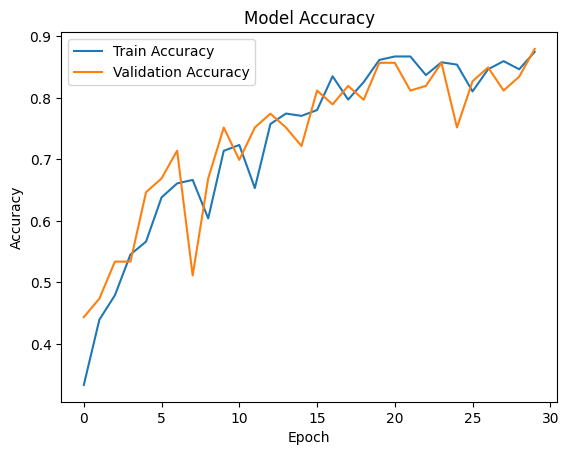

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8835 - loss: 0.3557
Test Accuracy: 0.88


In [22]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

## Confusion Matrix

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001698FFAF880> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step


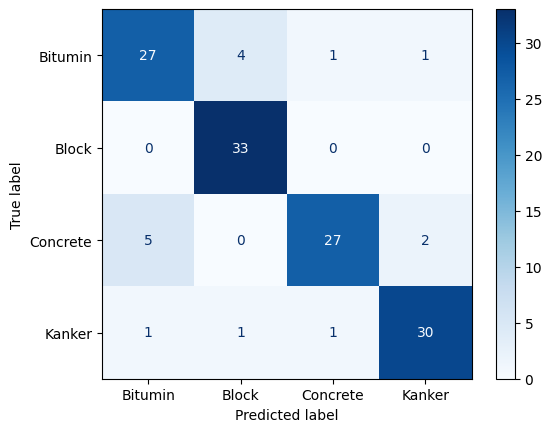

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_map.keys())
disp.plot(cmap='Blues')
plt.show()


## Save the Trained Model

In [24]:
model.save("Models/Model_Architecture(CS300-E).h5")

## Full Real-Time Sample Inference Code:

In [25]:
from tensorflow.keras.models import load_model
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load trained model and scaler
model = load_model("Models/Model_Architecture(CS300-E).h5")

# Recreate scaler from training (you may save and load if needed)
# For now, assuming you have same StandardScaler object as training
scaler = StandardScaler()

# Use all training data to fit the scaler again
X_flat = X.reshape(-1, X.shape[-1])
scaler.fit(X_flat)

StandardScaler()

In [26]:
# Load real-time test sample
sample_df = pd.read_csv(r"Dataset\Harshit_Preprocessed_Data-CS300\Bitumin\001_Abj_Bitumin_1_12-2_part_001.csv")
sample = sample_df[['X_Acc', 'Y_Acc', 'Z_Acc', 'X_Gyro', 'Y_Gyro', 'Z_Gyro']].values
sample_scaled = scaler.transform(sample).reshape(1, 300, 6)

# Predict
prediction = model.predict(sample_scaled)
predicted_class = np.argmax(prediction)
reverse_map = {v: k for k, v in label_map.items()}
print("Predicted Road Type:", reverse_map[predicted_class])


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 749ms/step
Predicted Road Type: Block
